# Model Training

## Import Packages & Libraries

In [1]:
# Basic Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Pre-processing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
# Modelling
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## Import Data

In [2]:
data = pd.read_csv('data/Student_Performance.csv')

**Top 5 Records**

In [3]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


**Remove Duplicates**

In [4]:
data.drop_duplicates(inplace=True, ignore_index=True)

## Prepare X and Y Variables

In [5]:
X = data.drop(columns='Performance Index')
X.head(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,Yes,9,1
1,4,82,No,4,2
2,8,51,Yes,7,2


In [6]:
y = data['Performance Index']
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9868    23.0
9869    58.0
9870    74.0
9871    95.0
9872    64.0
Name: Performance Index, Length: 9873, dtype: float64

## Create Column Transformer

In [7]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

scaler = StandardScaler()
encoder = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', encoder, cat_features),
        ('StandardScaler', scaler, num_features)
    ]
)

In [8]:
# Transform X
X = preprocessor.fit_transform(X)

In [9]:
X.shape

(9873, 6)

In [10]:
# Separate our dataset into train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7898, 6), (1975, 6), (7898,), (1975,))

## Create an Evaluation Function to give all metrics after Model Training

In [11]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r_squared = r2_score(true, predicted)
    return mae, rmse, r_squared

In [12]:
# All Models

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor(),
    'CatBoost Regressor': CatBoostRegressor(verbose=False),
    'XGBoost Regressor': XGBRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train & Test Dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model Performance for Training Set')
    print('- Root Mean Squared Error: {:.4f}'.format(model_train_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_train_mae))
    print('- R2 Score: {:.4f}'.format(model_train_r2))

    print('-'*50)

    print('Model Performance for Test Set')
    print('- Root Mean Squared Error: {:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_test_mae))
    print('- R2 Score: {:.4f}'.format(model_test_r2))

    r2_list.append(model_test_r2)

    print('='*50)
    print('\n')


Linear Regression
Model Performance for Training Set
- Root Mean Squared Error: 2.0358
- Mean Absolute Error: 1.6172
- R2 Score: 0.9887
--------------------------------------------------
Model Performance for Test Set
- Root Mean Squared Error: 2.0751
- Mean Absolute Error: 1.6470
- R2 Score: 0.9884


Ridge
Model Performance for Training Set
- Root Mean Squared Error: 2.0358
- Mean Absolute Error: 1.6172
- R2 Score: 0.9887
--------------------------------------------------
Model Performance for Test Set
- Root Mean Squared Error: 2.0751
- Mean Absolute Error: 1.6470
- R2 Score: 0.9884


Lasso
Model Performance for Training Set
- Root Mean Squared Error: 2.6798
- Mean Absolute Error: 2.1422
- R2 Score: 0.9805
--------------------------------------------------
Model Performance for Test Set
- Root Mean Squared Error: 2.7806
- Mean Absolute Error: 2.2139
- R2 Score: 0.9792


K-Neighbors Regressor
Model Performance for Training Set
- Root Mean Squared Error: 2.4392
- Mean Absolute Error: 1

## Model Evaluation Results

In [13]:
pd.DataFrame(data=list(zip(model_list, r2_list)), columns=['Model Name', 'R2 Score']).sort_values(by='R2 Score', ascending=False)

,Model Name,R2 Score
0,Linear Regression,0.988430
1,Ridge,0.988430
7,CatBoost Regressor,0.987591
8,XGBoost Regressor,0.986228
5,Random Forest Regressor,0.984743
2,Lasso,0.979225
3,K-Neighbors Regressor,0.976554
6,AdaBoost Regressor,0.975663
4,Decision Tree,0.975220


## Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)*100
print('Accuracy of the model is {:.2f}%'.format(r2))

Accuracy of the model is 98.84%


## Plot y_pred & y_test

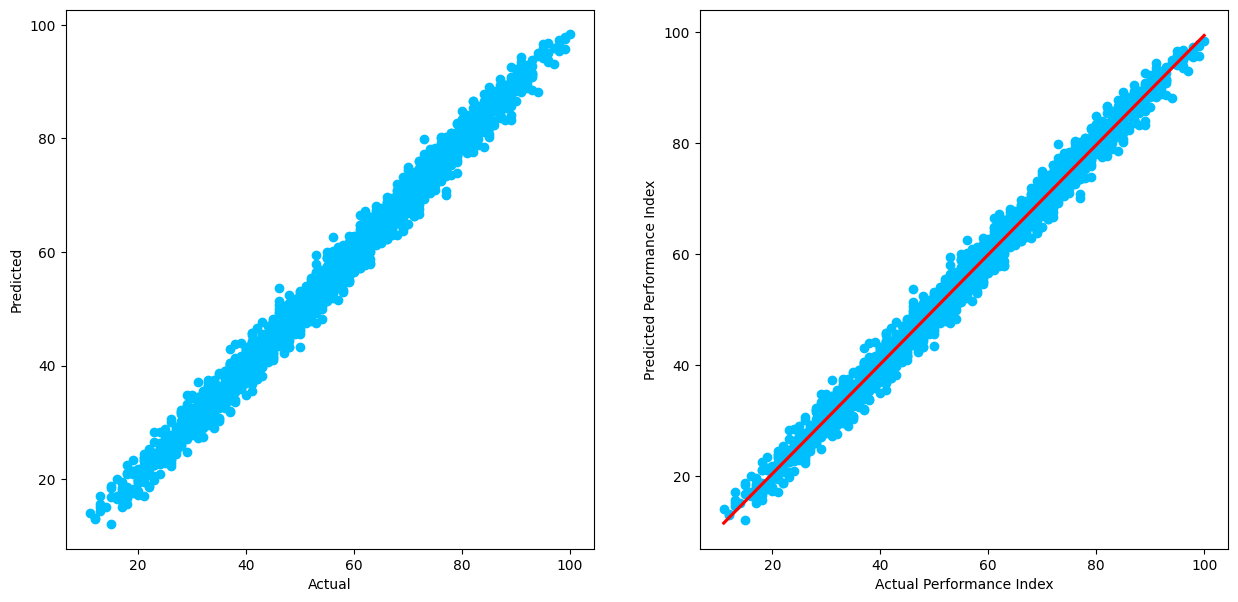

In [15]:
plt.figure(figsize=(15,7))

plt.subplot(121)
plt.scatter(y_test, y_pred, color='deepskyblue')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(122)
plt.scatter(y_test, y_pred, color='deepskyblue')
sns.regplot(x=y_test, y=y_pred, color='red', scatter=False)
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')

plt.show()

## Difference between Actual & Predicted Values

In [16]:
pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred, 'Difference': y_test-y_pred}).sort_index()

,Actual Value,Predicted Value,Difference
0,91.0,91.811619,-0.811619
3,36.0,36.543760,-0.543760
10,84.0,84.335823,-0.335823
12,27.0,27.064034,-0.064034
14,68.0,65.543924,2.456076
...,...,...,...
9862,27.0,25.289533,1.710467
9863,40.0,39.529705,0.470295
9866,55.0,55.946094,-0.946094
9869,58.0,56.449298,1.550702
